# Fitness Tracker Data – Cleaning, Integration & Analysis
**Audience:** Business analysts, product & marketing teams  |  **Tool:** Python (pandas, matplotlib, seaborn) in Google Colab

## Purpose
Turn nine raw smart-device (Fitbit / Fitabase-style) CSV exports into **one clean, analysis-ready dataset** and answer:
1. How active are users, and on which days / hours?
2. How do steps, calories, heart rate and sleep relate to each other?
3. How good is the data (duplicates, invalid values, coverage) and what can we trust?

## Contents
| # | Section |
|---|---------|
| 1 | Data sources & data dictionary |
| 2 | Important note on the original merge (why 81 columns / 4M rows is a problem) |
| 3 | Cleaning rules (duplicates + inconsistent data) |
| 4 | Code: load → clean → quality report |
| 5 | Code: build the analysis dataset (one row per user per day) |
| 6 | Code: 7 visualisations + how to read them |
| 7 | Auto-generated insights, KPI definitions, limitations, next steps |


## 1. Data sources & data dictionary

| File | Grain (one row = …) | Key columns | Business meaning |
|---|---|---|---|
| `dailySteps_merged.csv` | user × day | `Id`, `ActivityDay`, `StepTotal` | Daily step count |
| `heartrate_seconds_merged.csv` | user × ~5 seconds | `Id`, `Time`, `Value` | Heart rate (beats per minute) |
| `hourlyCalories_merged.csv` | user × hour | `Id`, `ActivityHour`, `Calories` | Calories burned per hour |
| `hourlyIntensities_merged.csv` | user × hour | `TotalIntensity`, `AverageIntensity` | Exercise intensity per hour |
| `hourlySteps_merged.csv` | user × hour | `StepTotal` | Steps per hour |
| `minuteCaloriesWide_merged.csv` | user × hour (60 minute columns) | `Calories00` … `Calories59` | Calories per minute, wide layout |
| `minuteIntensitiesNarrow_merged.csv` | user × minute | `ActivityMinute`, `Intensity` | 0 = sedentary, 1 = light, 2 = moderate, 3 = very active |
| `minuteSleep_merged.csv` | user × minute | `date`, `value`, `logId` | Sleep state: 1 = asleep, 2 = restless, 3 = awake |
| `weightLogInfo_merged.csv` | user × weigh-in | `WeightKg`, `WeightPounds`, `Fat`, `BMI`, `IsManualReport` | Body measurements |

`Id` = anonymous user identifier in every file.

## 2. Important note on the original merge

The original notebook used `pd.concat([...], ignore_index=True)` on all nine files. That **stacks the tables on top of each other** (rows appended), it does **not join them**. The result – **4,086,708 rows × 81 columns** – is a very sparse table where:
- every row has values in only a handful of columns (e.g. a heart-rate row has `Id`, `Time`, `Value` and ~78 empty columns);
- a heart-rate reading, a weigh-in and a sleep minute sit in the *same* column set but describe unrelated events;
- averages, correlations and duplicate checks on this table are **meaningless** (e.g. `Value` mixes heart rate and `value` mixes sleep states; `logId` and `LogId` are separate columns because of case).

**Fix used in this notebook:** clean each table separately (correct rules per table), aggregate every table to a common grain (**user × day**, and **user × hour** for hourly patterns) and **join on `Id` + `Date`**.

## 3. Cleaning rules

**Duplicates removed**
- *Exact duplicates* – identical rows.
- *Key duplicates* – same user + same timestamp (+ log id for sleep) with conflicting values → the first record is kept.

**Inconsistent / invalid data removed**

| Table | Rule (row is kept only if …) | Why |
|---|---|---|
| all | `Id` and timestamp are present and parse correctly | Unusable without them |
| dailySteps | 0 ≤ steps ≤ 80,000 | Negative / impossible counts |
| heart rate | 30 ≤ bpm ≤ 220 | Sensor glitches / physiologically implausible |
| hourlyCalories | 0 ≤ kcal ≤ 3,000 per hour | Negative / impossible |
| hourlyIntensities | totals ≥ 0 and average between 0 and 3 | Scale is 0–3 |
| hourlySteps | 0 ≤ steps ≤ 20,000 per hour | Impossible pace |
| minuteCaloriesWide | all 60 minute values ≥ 0 | Negative calories |
| minuteIntensities | intensity ∈ {0,1,2,3} | Undefined codes |
| minuteSleep | value ∈ {1,2,3} | Undefined codes |
| weightLog | 30–300 kg, BMI 10–70, and kg × 2.20462 ≈ pounds (±1) | Unit / entry errors |

**Cross-table consistency checks (flagged, not deleted)**
- Sum of hourly steps vs. daily steps (flag if difference > 5 %).
- Sum of 60 minute-calories vs. hourly calories (report count with difference > 1 kcal).

Missing values in optional fields (e.g. body `Fat`) are **kept as NaN** – they are not errors.

In [2]:
#importing libraries
import pandas as pd
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = "/content/"          # <- change if your CSVs are elsewhere
OUT_DIR  = "/content/"          # cleaned files & report are written here

FMT_DT = "%m/%d/%Y %I:%M:%S %p"  # e.g. 4/12/2016 7:21:00 AM
FMT_D  = "%m/%d/%Y"              # e.g. 4/12/2016

quality_log = []                 # one dict per table -> data-quality report

In [4]:
csv_files = [
    "/content/dailySteps_merged.csv",
    "/content/heartrate_seconds_merged.csv",
    "/content/hourlyCalories_merged.csv",
    "/content/hourlyIntensities_merged.csv",
    "/content/hourlySteps_merged.csv",
    "/content/minuteCaloriesWide_merged.csv",
    "/content/minuteIntensitiesNarrow_merged.csv",
    "/content/minuteSleep_merged.csv",
    "/content/weightLogInfo_merged.csv"
]

# Read and combine all CSV files
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

# Save as a single CSV
df.to_csv("/content/merged_data.csv", index=False)

print("CSV files merged successfully!")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("Shape:", df.shape)

CSV files merged successfully!
Total rows: 4086708
Total columns: 81
Shape: (4086708, 81)


In [5]:
# ---------- 4.2 Reusable cleaning function ----------
def clean_table(df, name, time_col, fmt, key_cols, valid_rule=None):
    # Standardise types, drop invalid rows and duplicates, and log what was removed.
    log = {"table": name, "rows_raw": len(df)}
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["Id"] = df["Id"].astype(str).str.strip()
    df[time_col] = pd.to_datetime(df[time_col], format=fmt, errors="coerce")

    # 1) missing / unparseable id or timestamp
    n = len(df)
    df = df.dropna(subset=["Id", time_col])
    log["invalid_id_or_timestamp"] = n - len(df)

    # 2) exact duplicate rows
    n = len(df)
    df = df.drop_duplicates()
    log["exact_duplicates"] = n - len(df)

    # 3) inconsistent / out-of-range values
    n = len(df)
    if valid_rule is not None:
        df = df[valid_rule(df)]
    log["invalid_or_inconsistent_values"] = n - len(df)

    # 4) same key recorded twice with different values -> keep first
    n = len(df)
    df = df.drop_duplicates(subset=key_cols, keep="first")
    log["duplicate_keys"] = n - len(df)

    log["rows_clean"] = len(df)
    log["pct_removed"] = round(100 * (log["rows_raw"] - log["rows_clean"]) / max(log["rows_raw"], 1), 2)
    quality_log.append(log)
    return df.reset_index(drop=True)


def read(name):
    return pd.read_csv(DATA_DIR + name, dtype={"Id": str})

In [8]:
# ---------- 4.3 Load and clean every table separately ----------
daily_steps = clean_table(
    read("dailySteps_merged.csv"), "dailySteps", "ActivityDay", FMT_D, ["Id", "ActivityDay"],
    lambda d: d["StepTotal"].between(0, 80000))

heart_rate = clean_table(
    read("heartrate_seconds_merged.csv"), "heartrate_seconds", "Time", FMT_DT, ["Id", "Time"],
    lambda d: d["Value"].between(30, 220))

hourly_cal = clean_table(
    read("hourlyCalories_merged.csv"), "hourlyCalories", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: d["Calories"].between(0, 3000))

hourly_int = clean_table(
    read("hourlyIntensities_merged.csv"), "hourlyIntensities", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: (d["TotalIntensity"] >= 0) & d["AverageIntensity"].between(0, 3))

hourly_steps = clean_table(
    read("hourlySteps_merged.csv"), "hourlySteps", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: d["StepTotal"].between(0, 20000))

minute_cal = clean_table(
    read("minuteCaloriesWide_merged.csv"), "minuteCaloriesWide", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: (d.filter(like="Calories") >= 0).all(axis=1))

minute_int = clean_table(
    read("minuteIntensitiesNarrow_merged.csv"), "minuteIntensitiesNarrow", "ActivityMinute", FMT_DT,
    ["Id", "ActivityMinute"],
    lambda d: d["Intensity"].isin([0, 1, 2, 3]))

sleep = clean_table(
    read("minuteSleep_merged.csv"), "minuteSleep", "date", FMT_DT, ["Id", "date", "logId"],
    lambda d: d["value"].isin([1, 2, 3]))

weight = clean_table(
    read("weightLogInfo_merged.csv"), "weightLogInfo", "Date", FMT_DT, ["Id", "Date"],
    lambda d: d["WeightKg"].between(30, 300) & d["BMI"].between(10, 70)
              & ((d["WeightKg"] * 2.20462 - d["WeightPounds"]).abs() < 1))

quality_report = pd.DataFrame(quality_log)
quality_report

,table,rows_raw,invalid_id_or_timestamp,exact_duplicates,invalid_or_inconsistent_values,duplicate_keys,rows_clean,pct_removed
0,dailySteps,940,0,0,0,0,940,0.00
1,heartrate_seconds,2483658,0,0,0,0,2483658,0.00
2,hourlyCalories,22099,0,0,0,0,22099,0.00
3,hourlyIntensities,22099,0,0,0,0,22099,0.00
4,hourlySteps,22099,0,0,0,0,22099,0.00
5,minuteCaloriesWide,21645,0,0,0,0,21645,0.00
6,minuteIntensitiesNarrow,1325580,0,0,0,0,1325580,0.00
7,minuteSleep,188521,0,543,0,0,187978,0.29
8,weightLogInfo,67,0,0,0,0,67,0.00


In [9]:
# ---------- 4.2 Reusable cleaning function ----------
def clean_table(df, name, time_col, fmt, key_cols, valid_rule=None):
    # Standardise types, drop invalid rows and duplicates, and log what was removed.
    log = {"table": name, "rows_raw": len(df)}
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["Id"] = df["Id"].astype(str).str.strip()
    df[time_col] = pd.to_datetime(df[time_col], format=fmt, errors="coerce")

    # 1) missing / unparseable id or timestamp
    n = len(df)
    df = df.dropna(subset=["Id", time_col])
    log["invalid_id_or_timestamp"] = n - len(df)

    # 2) exact duplicate rows
    n = len(df)
    df = df.drop_duplicates()
    log["exact_duplicates"] = n - len(df)

    # 3) inconsistent / out-of-range values
    n = len(df)
    if valid_rule is not None:
        df = df[valid_rule(df)]
    log["invalid_or_inconsistent_values"] = n - len(df)

    # 4) same key recorded twice with different values -> keep first
    n = len(df)
    df = df.drop_duplicates(subset=key_cols, keep="first")
    log["duplicate_keys"] = n - len(df)

    log["rows_clean"] = len(df)
    log["pct_removed"] = round(100 * (log["rows_raw"] - log["rows_clean"]) / max(log["rows_raw"], 1), 2)
    quality_log.append(log)
    return df.reset_index(drop=True)


def read(name):
    return pd.read_csv(DATA_DIR + name, dtype={"Id": str})

In [10]:
# ---------- 4.3 Load and clean every table separately ----------
daily_steps = clean_table(
    read("dailySteps_merged.csv"), "dailySteps", "ActivityDay", FMT_D, ["Id", "ActivityDay"],
    lambda d: d["StepTotal"].between(0, 80000))

heart_rate = clean_table(
    read("heartrate_seconds_merged.csv"), "heartrate_seconds", "Time", FMT_DT, ["Id", "Time"],
    lambda d: d["Value"].between(30, 220))

hourly_cal = clean_table(
    read("hourlyCalories_merged.csv"), "hourlyCalories", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: d["Calories"].between(0, 3000))

hourly_int = clean_table(
    read("hourlyIntensities_merged.csv"), "hourlyIntensities", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: (d["TotalIntensity"] >= 0) & d["AverageIntensity"].between(0, 3))

hourly_steps = clean_table(
    read("hourlySteps_merged.csv"), "hourlySteps", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: d["StepTotal"].between(0, 20000))

minute_cal = clean_table(
    read("minuteCaloriesWide_merged.csv"), "minuteCaloriesWide", "ActivityHour", FMT_DT, ["Id", "ActivityHour"],
    lambda d: (d.filter(like="Calories") >= 0).all(axis=1))

minute_int = clean_table(
    read("minuteIntensitiesNarrow_merged.csv"), "minuteIntensitiesNarrow", "ActivityMinute", FMT_DT,
    ["Id", "ActivityMinute"],
    lambda d: d["Intensity"].isin([0, 1, 2, 3]))

sleep = clean_table(
    read("minuteSleep_merged.csv"), "minuteSleep", "date", FMT_DT, ["Id", "date", "logId"],
    lambda d: d["value"].isin([1, 2, 3]))

weight = clean_table(
    read("weightLogInfo_merged.csv"), "weightLogInfo", "Date", FMT_DT, ["Id", "Date"],
    lambda d: d["WeightKg"].between(30, 300) & d["BMI"].between(10, 70)
              & ((d["WeightKg"] * 2.20462 - d["WeightPounds"]).abs() < 1))

quality_report = pd.DataFrame(quality_log)
quality_report

,table,rows_raw,invalid_id_or_timestamp,exact_duplicates,invalid_or_inconsistent_values,duplicate_keys,rows_clean,pct_removed
0,dailySteps,940,0,0,0,0,940,0.00
1,heartrate_seconds,2483658,0,0,0,0,2483658,0.00
2,hourlyCalories,22099,0,0,0,0,22099,0.00
3,hourlyIntensities,22099,0,0,0,0,22099,0.00
4,hourlySteps,22099,0,0,0,0,22099,0.00
5,minuteCaloriesWide,21645,0,0,0,0,21645,0.00
6,minuteIntensitiesNarrow,1325580,0,0,0,0,1325580,0.00
7,minuteSleep,188521,0,543,0,0,187978,0.29
8,weightLogInfo,67,0,0,0,0,67,0.00
9,dailySteps,940,0,0,0,0,940,0.00


In [11]:
# ---------- 4.4 Cross-table consistency checks (flag, don't delete) ----------
# (a) daily steps vs sum of hourly steps
daily_steps["Date"] = daily_steps["ActivityDay"].dt.normalize()
hourly_steps["Date"] = hourly_steps["ActivityHour"].dt.normalize()

steps_from_hourly = (hourly_steps.groupby(["Id", "Date"], as_index=False)["StepTotal"]
                     .sum().rename(columns={"StepTotal": "steps_from_hourly"}))
chk = daily_steps.merge(steps_from_hourly, on=["Id", "Date"], how="inner")
chk["diff_pct"] = (chk["StepTotal"] - chk["steps_from_hourly"]).abs() / chk["StepTotal"].replace(0, np.nan)
n_bad_steps = int((chk["diff_pct"] > 0.05).sum())
print(f"Steps check : {n_bad_steps:,} of {len(chk):,} user-days differ >5% between daily and hourly files")

# (b) hourly calories vs sum of 60 minute-calories
cal_cols = [c for c in minute_cal.columns if c.startswith("Calories")]
mc = minute_cal[["Id", "ActivityHour"]].copy()
mc["cal_from_minutes"] = minute_cal[cal_cols].sum(axis=1)
chk2 = mc.merge(hourly_cal[["Id", "ActivityHour", "Calories"]], on=["Id", "ActivityHour"], how="inner")
n_bad_cal = int(((chk2["cal_from_minutes"] - chk2["Calories"]).abs() > 1).sum())
print(f"Calories chk: {n_bad_cal:,} of {len(chk2):,} user-hours differ >1 kcal between minute and hourly files")

Steps check : 33 of 934 user-days differ >5% between daily and hourly files
Calories chk: 0 of 21,307 user-hours differ >1 kcal between minute and hourly files


Rows before cleaning: 8,173,416   after cleaning: 8,172,330   removed: 1,086


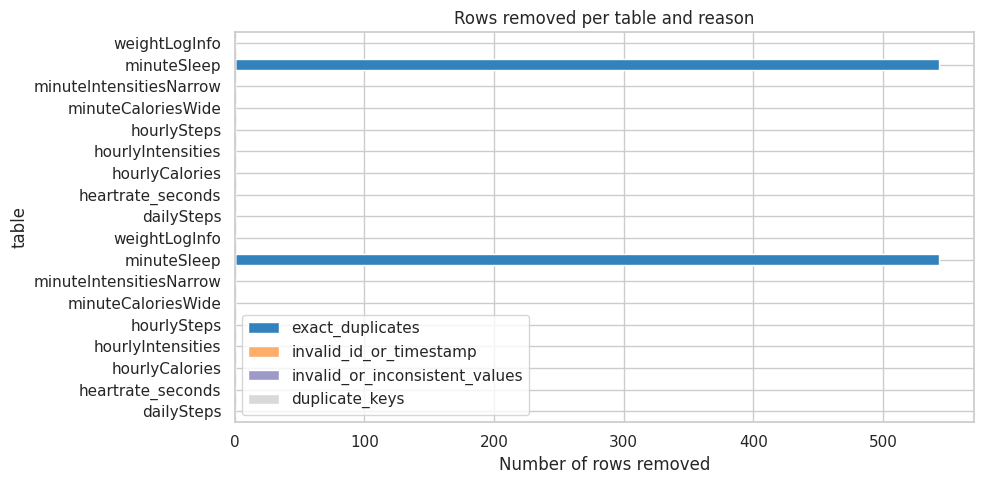

In [12]:
# ---------- 4.5 Data-quality summary (for the business report) ----------
total_raw   = quality_report["rows_raw"].sum()
total_clean = quality_report["rows_clean"].sum()
print(f"Rows before cleaning: {total_raw:,}   after cleaning: {total_clean:,}   removed: {total_raw-total_clean:,}")

ax = quality_report.set_index("table")[["exact_duplicates", "invalid_id_or_timestamp",
                                        "invalid_or_inconsistent_values", "duplicate_keys"]] \
     .plot(kind="barh", stacked=True, figsize=(10, 5), colormap="tab20c")
ax.set_title("Rows removed per table and reason")
ax.set_xlabel("Number of rows removed")
plt.tight_layout(); plt.show()

## 5. Build the analysis dataset (one row per user per day)

Each cleaned table is summarised to **user × day** and joined on `Id` + `Date` with a **left join from daily steps**, so the row count equals the number of valid user-days. Not every user has heart-rate, sleep or weight data – those columns are empty (NaN) for users without them; this is real coverage, not an error.

| Column | Definition |
|---|---|
| `Steps` | Daily step total |
| `Calories` | Sum of hourly calories |
| `TotalIntensity` | Sum of hourly intensity |
| `AvgHR`, `MinHR`, `MaxHR` | Mean / min / max heart rate that day (bpm) |
| `SleepHours` | Minutes flagged “asleep” ÷ 60 (calendar day of the timestamp) |
| `ActiveMinutes` | Minutes with intensity ≥ 1 |
| `VeryActiveMinutes` | Minutes with intensity = 3 |
| `WeightKg`, `BMI` | Last weigh-in of the day |
| `Weekday` | Day name |
| `ActivityLevel` | Sedentary <5k, Low active 5–7.5k, Somewhat active 7.5–10k, Active 10–12.5k, Highly active ≥12.5k steps |

In [13]:
#----- 5.1 Aggregate every table to user x day ----------
for df, col in [(heart_rate, "Time"), (hourly_cal, "ActivityHour"), (hourly_int, "ActivityHour"),
                (minute_int, "ActivityMinute"), (sleep, "date"), (weight, "Date")]:
    df["Date"] = df[col].dt.normalize()

cal_d   = hourly_cal.groupby(["Id", "Date"], as_index=False)["Calories"].sum()
int_d   = hourly_int.groupby(["Id", "Date"], as_index=False)["TotalIntensity"].sum()
hr_d    = (heart_rate.groupby(["Id", "Date"])["Value"].agg(AvgHR="mean", MinHR="min", MaxHR="max").reset_index())
sleep_d = (sleep[sleep["value"] == 1].groupby(["Id", "Date"]).size().div(60).rename("SleepHours").reset_index())
act_d   = (minute_int.assign(active=minute_int["Intensity"] >= 1, very=minute_int["Intensity"] == 3)
           .groupby(["Id", "Date"], as_index=False)
           .agg(ActiveMinutes=("active", "sum"), VeryActiveMinutes=("very", "sum")))
wt_d    = (weight.sort_values("Date").groupby(["Id", "Date"], as_index=False)
           .agg(WeightKg=("WeightKg", "last"), BMI=("BMI", "last")))

daily = daily_steps[["Id", "Date", "StepTotal"]].rename(columns={"StepTotal": "Steps"})
for part in (cal_d, int_d, hr_d, sleep_d, act_d, wt_d, steps_from_hourly):
    daily = daily.merge(part, on=["Id", "Date"], how="left")

daily["steps_mismatch_flag"] = ((daily["Steps"] - daily["steps_from_hourly"]).abs()
                                / daily["Steps"].replace(0, np.nan) > 0.05)
daily["Weekday"] = daily["Date"].dt.day_name()
daily["ActivityLevel"] = pd.cut(daily["Steps"], [-1, 4999, 7499, 9999, 12499, np.inf],
                                labels=["Sedentary", "Low active", "Somewhat active", "Active", "Highly active"])
daily = daily.drop(columns="steps_from_hourly")

print("Analysis dataset:", daily.shape)
daily.head()

Analysis dataset: (940, 16)


,Id,Date,Steps,Calories,TotalIntensity,AvgHR,MinHR,MaxHR,SleepHours,ActiveMinutes,VeryActiveMinutes,WeightKg,BMI,steps_mismatch_flag,Weekday,ActivityLevel
0,1503960366,2016-04-12,13162,1988.0,429.0,NaN,NaN,NaN,5.450000,366.0,25.0,NaN,NaN,False,Tuesday,Highly active
1,1503960366,2016-04-13,10735,1798.0,318.0,NaN,NaN,NaN,6.400000,257.0,21.0,NaN,NaN,False,Wednesday,Active
2,1503960366,2016-04-14,10460,1776.0,293.0,NaN,NaN,NaN,NaN,222.0,30.0,NaN,NaN,False,Thursday,Active
3,1503960366,2016-04-15,9762,1745.0,364.0,NaN,NaN,NaN,6.866667,272.0,29.0,NaN,NaN,False,Friday,Somewhat active
4,1503960366,2016-04-16,12669,1866.0,349.0,NaN,NaN,NaN,6.200000,267.0,36.0,NaN,NaN,False,Saturday,Highly active


In [14]:
#-------- 5.3 Save cleaned outputs ----------
daily.to_csv(OUT_DIR + "daily_master_clean.csv", index=False)
quality_report.to_csv(OUT_DIR + "data_quality_report.csv", index=False)
print("Saved: daily_master_clean.csv, data_quality_report.csv")

Saved: daily_master_clean.csv, data_quality_report.csv


### Visual 1 – Distribution of daily steps
**Shows:** how many user-days fall into each step range; dashed lines = mean and median.
**How to read:** a bar cluster far below 10,000 means most usage is under the common health target; a large gap between mean and median signals a few very active outliers.
**Business use:** size the “under-active” audience for coaching / challenge features.

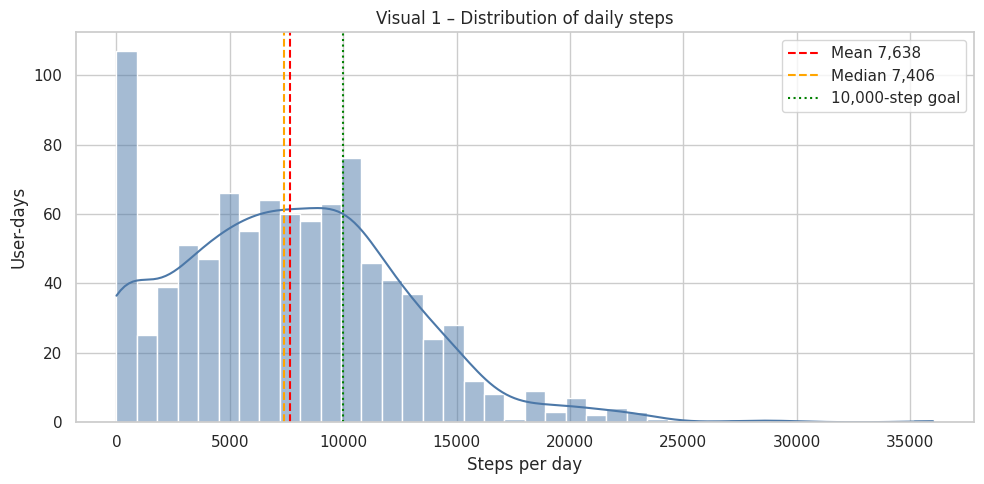

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(daily["Steps"], bins=40, kde=True, color="#4C78A8", ax=ax)
ax.axvline(daily["Steps"].mean(),   color="red",    ls="--", label=f"Mean {daily['Steps'].mean():,.0f}")
ax.axvline(daily["Steps"].median(), color="orange", ls="--", label=f"Median {daily['Steps'].median():,.0f}")
ax.axvline(10000, color="green", ls=":", label="10,000-step goal")
ax.set_title("Visual 1 – Distribution of daily steps"); ax.set_xlabel("Steps per day"); ax.set_ylabel("User-days")
ax.legend(); plt.tight_layout(); plt.show()

### Visual 2 – Average steps by weekday
**Shows:** mean steps for each day of the week (error bars = 95 % confidence interval).
**How to read:** compare weekdays vs weekend; overlapping error bars mean the difference may not be real.
**Business use:** time push notifications and promotions for the low-activity days.

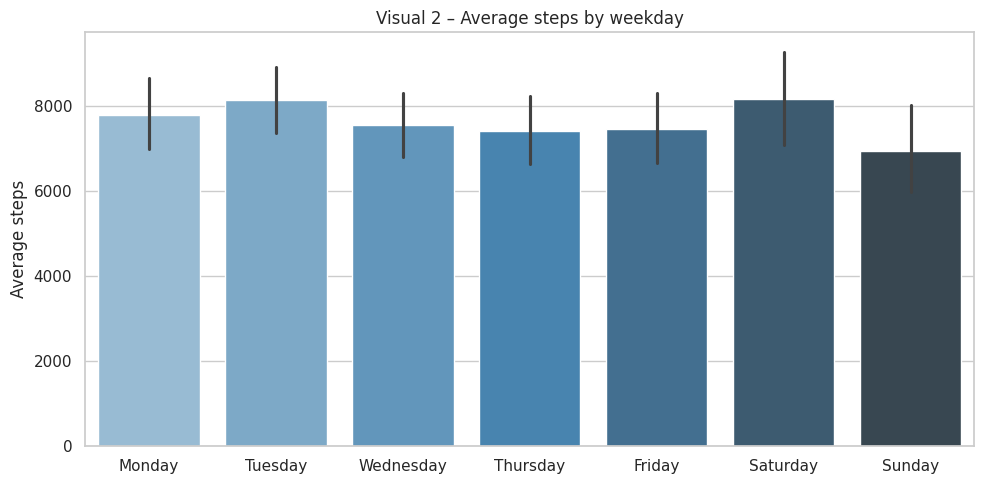

In [16]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=daily, x="Weekday", y="Steps", order=order, palette="Blues_d", errorbar=("ci", 95), ax=ax)
ax.set_title("Visual 2 – Average steps by weekday"); ax.set_xlabel(""); ax.set_ylabel("Average steps")
plt.tight_layout(); plt.show()

### Visual 3 – Hour-of-day profile: steps and calories
**Shows:** average steps (left axis) and calories (right axis) for each hour, all users combined.
**How to read:** peaks = commute / lunch / workout / evening walk windows; flat night hours = sleep.
**Business use:** choose the best hour to send reminders, and plan support/marketing timing.

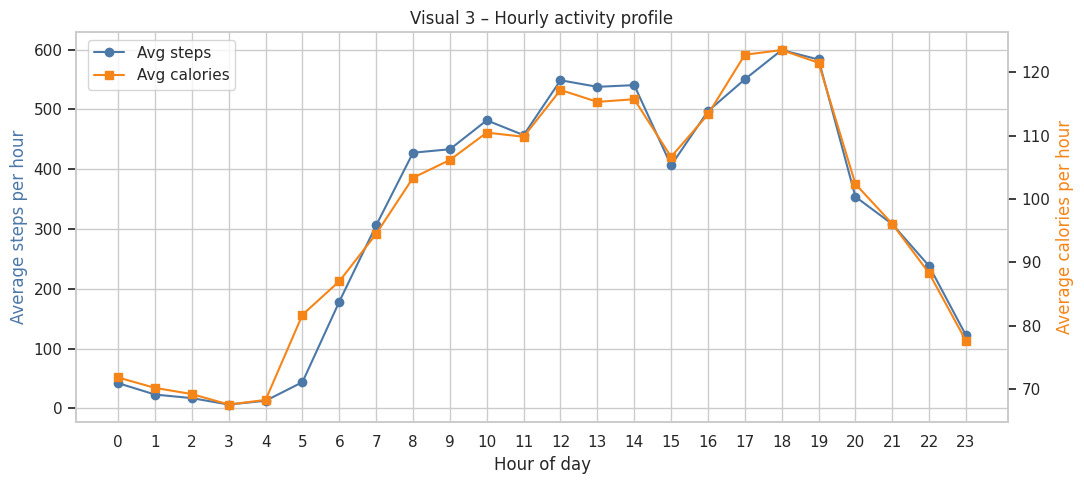

In [17]:
hs = hourly_steps.assign(Hour=hourly_steps["ActivityHour"].dt.hour).groupby("Hour")["StepTotal"].mean()
hc = hourly_cal.assign(Hour=hourly_cal["ActivityHour"].dt.hour).groupby("Hour")["Calories"].mean()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(hs.index, hs.values, marker="o", color="#4C78A8", label="Avg steps")
ax1.set_xlabel("Hour of day"); ax1.set_ylabel("Average steps per hour", color="#4C78A8")
ax1.set_xticks(range(0, 24))
ax2 = ax1.twinx()
ax2.plot(hc.index, hc.values, marker="s", color="#F58518", label="Avg calories")
ax2.set_ylabel("Average calories per hour", color="#F58518"); ax2.grid(False)
ax1.set_title("Visual 3 – Hourly activity profile")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.92))
plt.tight_layout(); plt.show()

### Visual 4 – Steps vs calories burned (daily)
**Shows:** each dot is one user-day; the line is the fitted trend.
**How to read:** a tight upward cloud = steps explain most calorie burn; vertical spread at the same steps = differences in body size / non-step exercise.
**Business use:** validates using steps as a simple proxy for energy expenditure in the app.

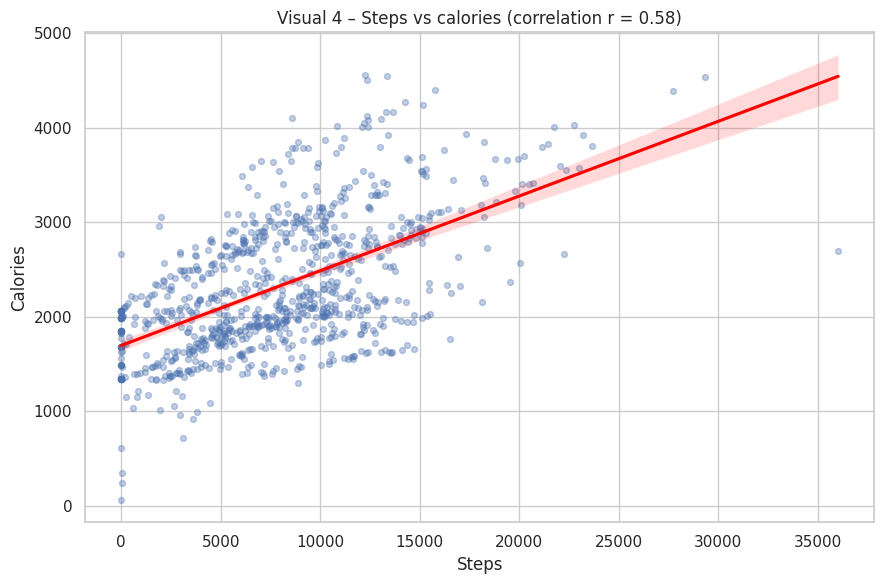

In [18]:
plot_df = daily.dropna(subset=["Steps", "Calories"])
corr = plot_df["Steps"].corr(plot_df["Calories"])
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=plot_df, x="Steps", y="Calories", scatter_kws={"alpha": 0.35, "s": 18},
            line_kws={"color": "red"}, ax=ax)
ax.set_title(f"Visual 4 – Steps vs calories (correlation r = {corr:.2f})")
plt.tight_layout(); plt.show()

### Visual 5 – Average heart rate by hour of day
**Shows:** mean bpm for every hour across all heart-rate users.
**How to read:** the lowest values usually occur overnight (resting), the highest during exercise windows.
**Business use:** sanity check of sensor data and a basis for “resting heart rate” and recovery insights.
*(Only users with heart-rate data are included – see coverage table in 5.2.)*

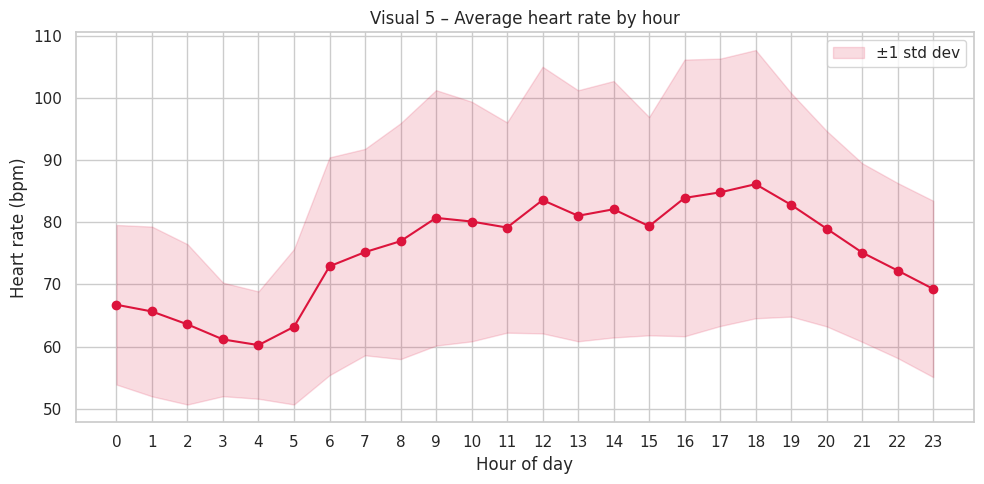

In [19]:
hr_hour = heart_rate.assign(Hour=heart_rate["Time"].dt.hour).groupby("Hour")["Value"].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hr_hour.index, hr_hour["mean"], marker="o", color="crimson")
ax.fill_between(hr_hour.index, hr_hour["mean"] - hr_hour["std"], hr_hour["mean"] + hr_hour["std"],
                color="crimson", alpha=0.15, label="±1 std dev")
ax.set_xticks(range(0, 24)); ax.set_xlabel("Hour of day"); ax.set_ylabel("Heart rate (bpm)")
ax.set_title("Visual 5 – Average heart rate by hour"); ax.legend()
plt.tight_layout(); plt.show()

### Visual 6 – Sleep duration by weekday
**Shows:** box-plot of nightly hours asleep for each weekday (box = middle 50 %, line = median, dots = outliers).
**How to read:** compare medians; long boxes = inconsistent sleep habits.
**Business use:** sleep-coaching content, weekend “social jet-lag” insights.
*(Only sleep-tracking users; very short values may be naps or partial nights.)*

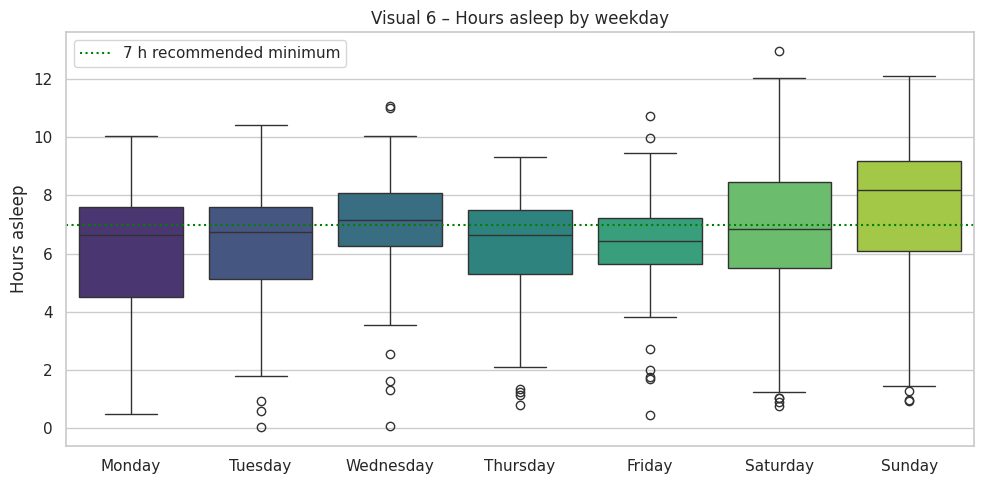

In [20]:
sleep_df = daily.dropna(subset=["SleepHours"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sleep_df, x="Weekday", y="SleepHours", order=order, palette="viridis", ax=ax)
ax.axhline(7, color="green", ls=":", label="7 h recommended minimum")
ax.set_title("Visual 6 – Hours asleep by weekday"); ax.set_xlabel(""); ax.set_ylabel("Hours asleep"); ax.legend()
plt.tight_layout(); plt.show()

### Visual 7 – Correlation heat-map of key metrics
**Shows:** correlation (−1 to +1) between every pair of daily metrics.
**How to read:** dark red = move together, dark blue = move in opposite directions, near 0 = no linear relation. Correlation is **not** causation.
**Business use:** find which metrics are redundant and which relationships (e.g. activity vs sleep) deserve a deeper study.

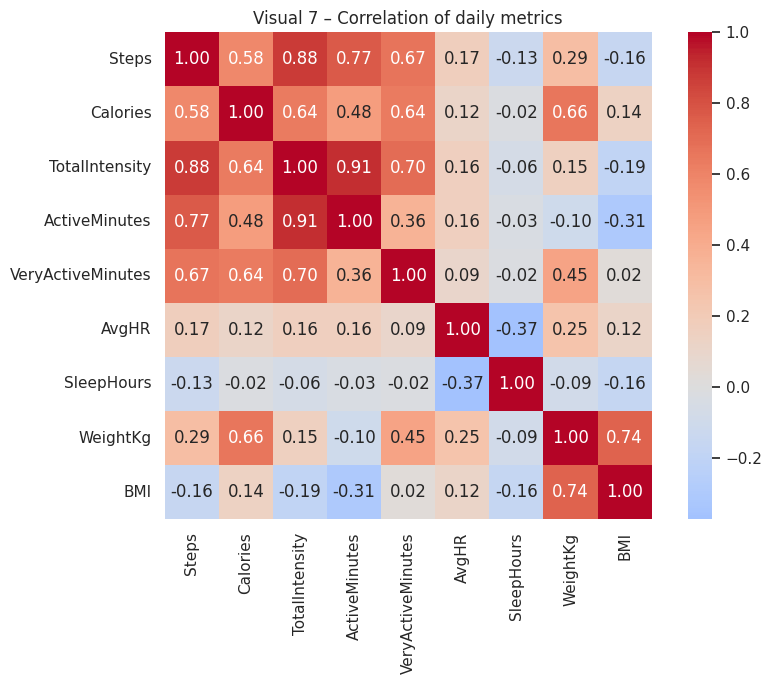

In [21]:
num_cols = ["Steps", "Calories", "TotalIntensity", "ActiveMinutes", "VeryActiveMinutes",
            "AvgHR", "SleepHours", "WeightKg", "BMI"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(daily[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Visual 7 – Correlation of daily metrics")
plt.tight_layout(); plt.show()

In [22]:
best_day  = daily.groupby("Weekday")["Steps"].mean().idxmax()
worst_day = daily.groupby("Weekday")["Steps"].mean().idxmin()
peak_hour = hs.idxmax()
level_share = daily["ActivityLevel"].value_counts(normalize=True).mul(100).round(1)
share_goal  = (daily["Steps"] >= 10000).mean() * 100

print(f"Users analysed                : {daily['Id'].nunique()}  |  User-days: {len(daily):,}")
print(f"Average / median daily steps  : {daily['Steps'].mean():,.0f} / {daily['Steps'].median():,.0f}")
print(f"User-days reaching 10k steps  : {share_goal:.1f}%")
print(f"Most / least active weekday   : {best_day} / {worst_day}")
print(f"Peak activity hour            : {peak_hour}:00")
print(f"Steps-calories correlation    : {daily['Steps'].corr(daily['Calories']):.2f}")
if daily["SleepHours"].notna().any():
    print(f"Average sleep (tracked users) : {daily['SleepHours'].mean():.1f} h  "
          f"({(daily['SleepHours'] < 7).mean()*100:.0f}% of nights under 7 h)")
print("\nShare of user-days by activity level (%):")
print(level_share.to_string())

Users analysed                : 33  |  User-days: 940
Average / median daily steps  : 7,638 / 7,406
User-days reaching 10k steps  : 32.2%
Most / least active weekday   : Saturday / Sunday
Peak activity hour            : 18:00
Steps-calories correlation    : 0.58
Average sleep (tracked users) : 6.5 h  (25% of nights under 7 h)

Share of user-days by activity level (%):
ActivityLevel
Sedentary          32.2
Low active         18.2
Somewhat active    17.3
Active             16.9
Highly active      15.3


## 8. Business interpretation guide

**How to turn the outputs into decisions**
| Finding to check | Decision it supports |
|---|---|
| Large share of *Sedentary / Low active* days | Launch beginner challenges, streaks, gentle reminders |
| Weekend vs weekday gap (Visual 2) | Weekend-specific campaigns or content |
| Hourly peaks (Visual 3) | Schedule push notifications 1 h before the low-activity windows |
| Strong steps↔calories link (Visual 4) | Use steps as headline KPI; add heart-rate for accuracy |
| Sleep < 7 h on many nights (Visual 6) | Bedtime reminders, sleep-score feature |
| Low coverage of heart-rate / weight / sleep | Encourage device wear at night, sync body-composition scale |

**KPI definitions**
- *Average daily steps* = mean of `Steps` over all user-days.
- *Goal attainment %* = share of user-days with ≥ 10,000 steps.
- *Active minutes* = minutes with intensity ≥ 1.
- *Data completeness %* = share of non-missing values per column (table in 5.2).

## 9. Limitations & assumptions
- Analysis is **descriptive**; correlations do not prove causes.
- Very small user sample (Fitabase-style data has roughly 30 users): results describe this sample, not the whole market.
- Heart-rate, sleep and especially weight data exist for only a subset of users.
- Sleep is assigned to the calendar day of each timestamp; nights that cross midnight are split across two days.
- Thresholds in Section 3 are reasonable defaults – adjust them to your device / population if needed.
- Removing “first of duplicate keys” assumes the first record is the valid one.
- Some days at the start/end of the study may be partial (device not worn all day) and can pull averages down.

## 10. Recommended next steps
1. Filter to “complete” days (e.g. ≥ 1,000 steps and ≥ 16 hours of data) to exclude days the device was not worn.
2. Segment users (e.g. K-means on steps, active minutes, sleep) for targeted marketing.
3. Track week-over-week trends and retention (days with data per user).
4. Build a dashboard (Power BI / Tableau / Looker Studio) from `daily_master_clean.csv`.

## 11. Output files
| File | Content |
|---|---|
| `daily_master_clean.csv` | Analysis dataset, one row per user per day |
| `data_quality_report.csv` | Rows removed per table and reason |